In [1]:
!pip install missingno statsmodels

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from scipy import stats
from scipy.stats import chi2_contingency
import statsmodels.api as sm

In [3]:
data = pd.read_csv("Students_Grading_Dataset.csv")
data.head()

,Student_ID,First_Name,Last_Name,Email,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,...,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
0,S1000,Omar,Williams,student0@university.com,Female,22,Engineering,52.29,55.03,57.82,...,85.90,56.09,F,6.2,No,Yes,High School,Medium,5,4.7
1,S1001,Maria,Brown,student1@university.com,Male,18,Engineering,97.27,97.23,45.80,...,55.65,50.64,A,19.0,No,Yes,NaN,Medium,4,9.0
2,S1002,Ahmed,Jones,student2@university.com,Male,24,Business,57.19,67.05,93.68,...,73.79,70.30,D,20.7,No,Yes,Master's,Low,6,6.2
3,S1003,Omar,Williams,student3@university.com,Female,24,Mathematics,95.15,47.79,80.63,...,92.12,61.63,A,24.8,Yes,Yes,High School,High,3,6.7
4,S1004,John,Smith,student4@university.com,Female,23,CS,54.18,46.59,78.89,...,68.42,66.13,F,15.4,Yes,Yes,High School,High,2,7.1


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  5000 non-null   object 
 1   First_Name                  5000 non-null   object 
 2   Last_Name                   5000 non-null   object 
 3   Email                       5000 non-null   object 
 4   Gender                      5000 non-null   object 
 5   Age                         5000 non-null   int64  
 6   Department                  5000 non-null   object 
 7   Attendance (%)              4484 non-null   float64
 8   Midterm_Score               5000 non-null   float64
 9   Final_Score                 5000 non-null   float64
 10  Assignments_Avg             4483 non-null   float64
 11  Quizzes_Avg                 5000 non-null   float64
 12  Participation_Score         5000 non-null   float64
 13  Projects_Score              5000 

In [5]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,5000.0,21.048400,1.989786,18.00,19.0000,21.000,23.0000,24.00
Attendance (%),4484.0,75.431409,14.372446,50.01,63.2650,75.725,87.4725,100.00
Midterm_Score,5000.0,70.326844,17.213209,40.00,55.4575,70.510,84.9700,99.98
Final_Score,5000.0,69.640788,17.238744,40.00,54.6675,69.735,84.5000,99.98
Assignments_Avg,4483.0,74.798673,14.411799,50.00,62.0900,74.810,86.9700,99.98
Quizzes_Avg,5000.0,74.910728,14.504281,50.03,62.4900,74.695,87.6300,99.96
Participation_Score,5000.0,4.980024,2.890136,0.00,2.4400,4.955,7.5000,10.00
Projects_Score,5000.0,74.924860,14.423415,50.01,62.3200,74.980,87.3675,100.00
Total_Score,5000.0,75.121804,14.399941,50.02,62.8350,75.395,87.6525,99.99
Study_Hours_per_Week,5000.0,17.658860,7.275864,5.00,11.4000,17.500,24.1000,30.00


In [6]:
data.duplicated().sum()

0

In [7]:
data.isnull().sum().sum()

2827

In [8]:
df = data.copy()

In [9]:
total_nulls = (df.isnull().sum().sum() / (df.shape[0] * df.shape[1])) * 100
print(f"The total missing values: {total_nulls} %")

The total missing values: 2.4582608695652173 %


In [10]:
null_per_column = df.isnull().sum() / df.shape[0] * 100
null_per_column

Student_ID                     0.00
First_Name                     0.00
Last_Name                      0.00
Email                          0.00
Gender                         0.00
Age                            0.00
Department                     0.00
Attendance (%)                10.32
Midterm_Score                  0.00
Final_Score                    0.00
Assignments_Avg               10.34
Quizzes_Avg                    0.00
Participation_Score            0.00
Projects_Score                 0.00
Total_Score                    0.00
Grade                          0.00
Study_Hours_per_Week           0.00
Extracurricular_Activities     0.00
Internet_Access_at_Home        0.00
Parent_Education_Level        35.88
Family_Income_Level            0.00
Stress_Level (1-10)            0.00
Sleep_Hours_per_Night          0.00
dtype: float64

In [11]:
print(null_per_column[null_per_column > 0])

Attendance (%)            10.32
Assignments_Avg           10.34
Parent_Education_Level    35.88
dtype: float64


In [12]:
df["Attendance (%)"] = df["Attendance (%)"].fillna(df["Attendance (%)"].median())

In [13]:
df["Assignments_Avg"] = df["Assignments_Avg"].fillna(df["Assignments_Avg"].median())

In [14]:
df["Parent_Education_Level"].unique()

array(['High School', nan, "Master's", 'PhD', "Bachelor's"], dtype=object)

In [15]:
df["Parent_Education_Level"] = df["Parent_Education_Level"].fillna(df["Parent_Education_Level"].mode()[0])

In [16]:
df.isnull().sum()

Student_ID                    0
First_Name                    0
Last_Name                     0
Email                         0
Gender                        0
Age                           0
Department                    0
Attendance (%)                0
Midterm_Score                 0
Final_Score                   0
Assignments_Avg               0
Quizzes_Avg                   0
Participation_Score           0
Projects_Score                0
Total_Score                   0
Grade                         0
Study_Hours_per_Week          0
Extracurricular_Activities    0
Internet_Access_at_Home       0
Parent_Education_Level        0
Family_Income_Level           0
Stress_Level (1-10)           0
Sleep_Hours_per_Night         0
dtype: int64

In [17]:
categorical_cols = df.iloc[:, 4:].select_dtypes(include=["object"])
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.to_list()
categorical_cols.columns

Index(['Gender', 'Department', 'Grade', 'Extracurricular_Activities',
       'Internet_Access_at_Home', 'Parent_Education_Level',
       'Family_Income_Level'],
      dtype='object')

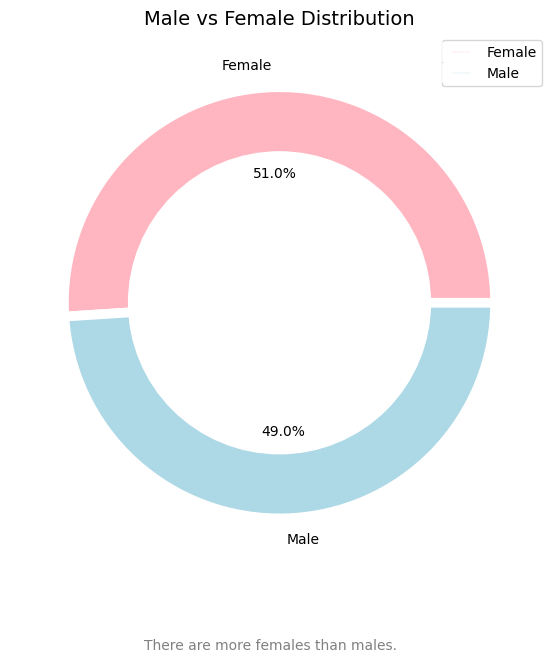

In [18]:
plt.figure(figsize=(7, 7))
my_circle = plt.Circle( (0, 0), 0.7, color="white")

plt.pie(df["Gender"].value_counts(), labels=df["Gender"].unique(), colors=["lightpink", "lightblue"], autopct="%1.1f%%", wedgeprops = {"linewidth": 7, "edgecolor": "white"})

p = plt.gcf()
p.gca().add_artist(my_circle)
plt.legend()
plt.title("Male vs Female Distribution", fontsize=14)

plt.figtext(0.5, -0.001, "There are more females than males.", ha="center", fontsize=10, color="gray")
plt.show()

<Figure size 1000x500 with 0 Axes>

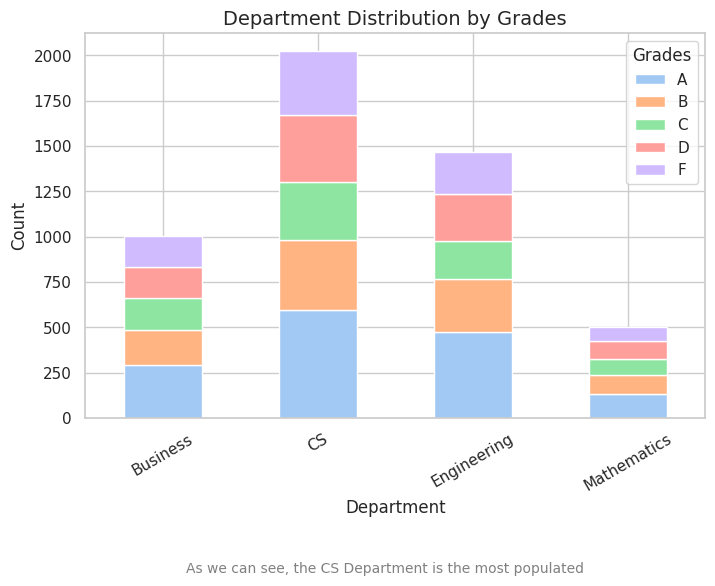

In [19]:
sns.set_theme(style="whitegrid")
dept_counts = pd.crosstab(df["Department"], df["Grade"])

bar_colors = sns.color_palette("pastel")

plt.figure(figsize=(10, 5))
dept_counts.plot(kind="bar", stacked=True, color=bar_colors, figsize=(8, 5))

plt.title("Department Distribution by Grades", fontsize=14)
plt.xlabel("Department", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.xticks(rotation=30)
plt.legend(title="Grades")

plt.figtext(0.5, -0.2, "As we can see, the CS Department is the most populated", ha="center", fontsize=10, color="gray")
plt.show()

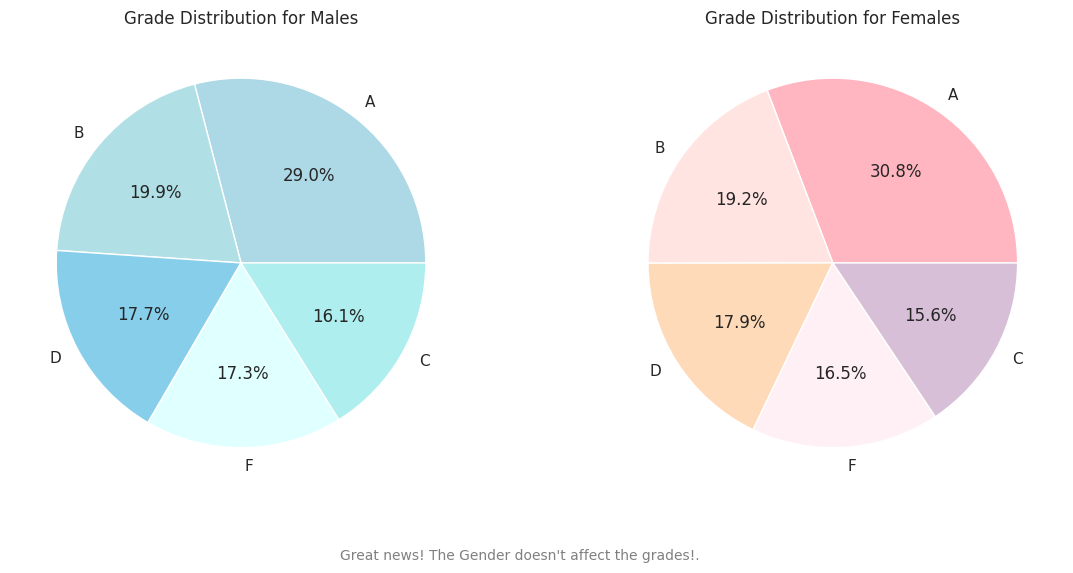

In [20]:
male_grade_counts = df[df["Gender"] == "Male"]["Grade"].value_counts()
female_grade_counts = df[df["Gender"] == "Female"]["Grade"].value_counts()

male_colors = ["lightblue", "powderblue", "skyblue", "lightcyan", "paleturquoise"]
female_colors = ["lightpink", "mistyrose", "peachpuff", "lavenderblush", "thistle"]

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.pie(male_grade_counts, labels=male_grade_counts.index, autopct='%1.1f%%', colors=male_colors)
plt.title("Grade Distribution for Males")

plt.subplot(1, 2, 2)
plt.pie(female_grade_counts, labels=female_grade_counts.index, autopct="%1.1f%%", colors=female_colors)
plt.title("Grade Distribution for Females")
plt.figtext(0.5, -0.0001, "Great news! The Gender doesn't affect the grades!.", ha="center", fontsize=10, color="gray")

plt.show()

<Figure size 1000x600 with 0 Axes>

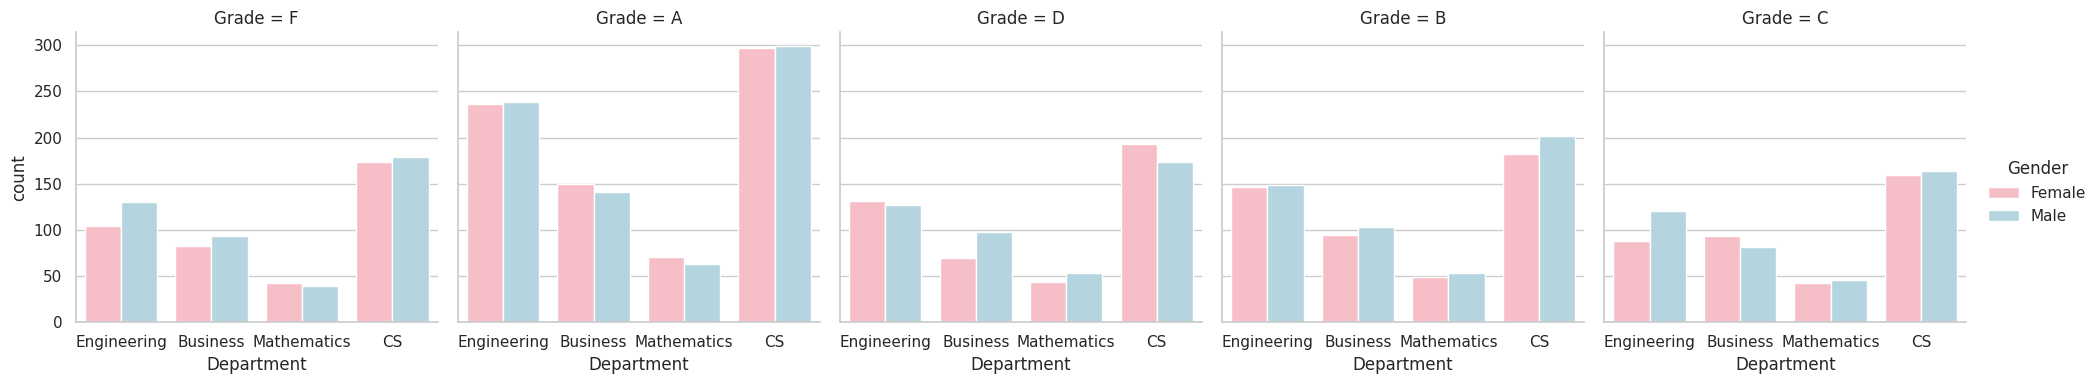

In [21]:
sns.set_theme(style="whitegrid")

custom_palette = {"Male": "lightblue", "Female": "lightpink"}
plt.figure(figsize=(10, 6))

sns.catplot(x="Department", hue="Gender", col="Grade", data=df, kind="count", height=4, aspect=1, palette=custom_palette)
plt.show()

AttributeError: module 'matplotlib.pyplot' has no attribute 'showw'

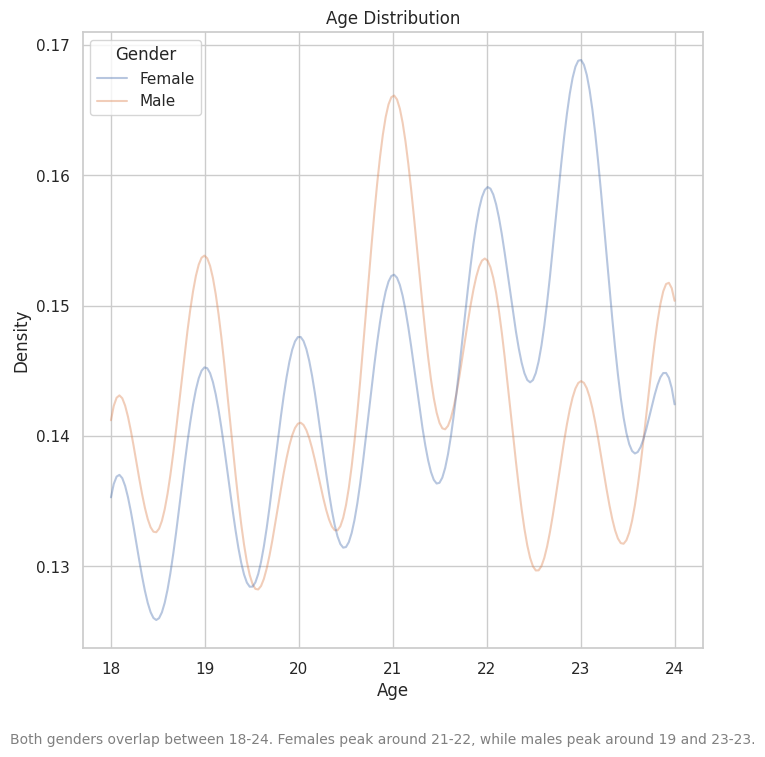

In [22]:
plt.figure(figsize=(8, 8))
sns.set_theme(style="whitegrid")

sns.kdeplot(data=df, x="Age", hue="Gender", cut=0, fill=False, common_norm=False, alpha=0.4)
plt.title("Age Distribution")
plt.figtext(0.5, -0.01, "Both genders overlap between 18-24. Females peak around 21-22, while males peak around 19 and 23-23.", ha="center", fontsize=10, color="gray")
plt.showw()

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x=df["Parent_Education_Level"], hue=df["Grade"], palette="Set2")

plt.xticks(rotation=45)
plt.title("Distribution of Parent Education Levels by Student Grades", fontsize=14, fontweight="bold")
plt.xlabel("Parent Education Level", fontsize=12, fontweight="bold")
plt.ylabel("Count", fontsize=12, fontweight="bold")
plt.figtext(0.5, -0.05, "Insight: Higher parental education levels tend to correlate with more A grades.", ha="center", fontsize=10, color="gray")
plt.tight_layout()
plt.show()

In [ ]:
ordered_df = df["Stress_Level (1-10)"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.stem(ordered_df.index, ordered_df.values, linefmt="b-", markerfmt="bo", basefmt="r-")

plt.xticks(ordered_df.index)
plt.xlabel("Stress Level (1-10)", fontsize=12, fontweight="bold")
plt.ylabel("Number of Students", fontsize=12, fontweight="bold")
plt.title("Distribution of Students Stress Levels", fontsize=14, fontweight="bold")
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x="Stress_Level (1-10)", y="Total_Score", data=df, palette="coolwarm")

plt.xlabel("Stress Level (1-10)", fontsize=12, fontweight="bold")
plt.ylabel("Total Score", fontsize=12, fontweight="bold")
plt.title("Stress Level vs. Student Performance", fontsize=14, fontweight="bold")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.figtext(0.5, -0.01, "Insight: Moderate stress boosts performance, while too little or too much stress can be detrimental.", ha="center", fontsize=10, color="gray")
plt.show()

In [ ]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 5))
sns.boxplot(x="Grade", y="Sleep_Hours_per_Night", data=df, palette="pastel")

plt.title("Sleep Hours per Night vs. Grade", fontsize=14, fontweight="bold")
plt.xlabel("Grade", fontsize=12)
plt.ylabel("Sleep Hours per Night", fontsize=12)
plt.figtext(0.5, -0.1, "Insight: the boxplot does not reveal a clear linear relationship between sleep hours and grades.", ha="center", fontsize=10, color="gray")

plt.show()

In [ ]:
plt.figure(figsize=(8, 8))

my_circle = plt.Circle((0, 0), 0.7, color='white')
income_counts = df['Family_Income_Level'].value_counts()

plt.pie(income_counts,
        labels=income_counts.index,
        colors=['lightgreen', 'lightblue', 'lightsalmon'],
        autopct='%1.1f%%',
        wedgeprops={'linewidth': 3, 'edgecolor': 'white'})

p = plt.gcf()
p.gca().add_artist(my_circle)

plt.legend(title="Income Levels")
plt.title("Distribution of Family Income Levels", fontsize=14, fontweight='bold')
plt.figtext(0.5, -0.001,
            "Insight: High-income families are a minority. ",
            ha="center", fontsize=10, color="gray")

plt.show()

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(x="Family_Income_Level", hue="Grade", data=df, palette="Set3")

plt.title("Family Income Level vs. Grades", fontsize=14, fontweight="bold")
plt.xlabel("Family Income Level", fontsize=12)
plt.ylabel("Count of Students", fontsize=12)

plt.figtext(0.5, -0.1, "Insight: most high-performance students come from low- and medium-income families.", ha="center", fontsize=10, color="gray")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [ ]:
df["Study_Hours_per_Week_bins"] = pd.cut(df["Study_Hours_per_Week"], bins=[0, 5, 10, 15, 20, 25, 30, df["Study_Hours_per_Week"].max() + 1], labels=["0-5", "6-10", "11-15", "16-20", "21-25", "26-30", "30+"], include_lowest=True)

df["Study_Hours_per_Week_bins"].value_counts()

In [ ]:
plt.figure(figsize=(8, 5))
sns.pointplot(x="Study_Hours_per_Week_bins", y="Final_Score", data=df, errorbar=None, color="lightblue", markers="o", linestyle="solid")

plt.title("Final Score by Study Hours per Week", fontsize=14, fontweight="bold", color="black")
plt.xlabel("Study Hours per Week (Binned)", fontsize=12)
plt.ylabel("Final Score", fontsize=12)
plt.xticks(rotation=45)
plt.yticks()
plt.grid(True, linestyle="==", alpha=0.6)
plt.figtext(0.5, -0.1, "Insight: Most high-performing students study between 21 and 25 hours per weel..", ha="center", fontsize=10, color="gray")

plt.show()

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="Attendance (%)", color="lightsalmon", bins=15, kde=True, alpha=0.8)

plt.title("Distribution of Attendance (%) Among High-Performance Students", fontsize=14, fontweight="bold")
plt.xlabel("Attendance (%)", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

In [ ]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.boxplot(x="Grade", y="Attendance (%)", data=df, palette="Set3")

plt.title("Attendance vs. Grade", fontsize=14, fontweight="bold")
plt.xlabel("Grade", fontsize=12)
plt.ylabel("Attendance (%)", fontsize=12)
plt.figtext(0.5, -0.1, "Insight: Students with higher attendance tend to achieve higher total scores.", ha="center", fontsize=10, color="gray")
plt.show()

In [ ]:
internet_counts = df["Internet_Access_at_Home"].value_counts()

colors = ["lightblue", "lightcoral"]

plt.figure(figsize=(6, 6))
plt.pie(internet_counts, labels=internet_counts.index, autopct="%1.1f%%", colors=colors, startangle=90, textprops={"fontsize":12})

plt.title("Distribution of Internet Access at Home", fontsize=14, fontweight="bold")
plt.show()

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(x=df["Grade"], hue=df["Internet_Access_at_Home"], palette=["lightblue", "lightcoral"])

plt.title("Internet Access vs. Grade Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Grade", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.figtext(0.5, -0.1, "Insight: Having internet access positively influences student performance.", ha="center", fontsize=10, color="gray")

plt.show()

In [ ]:
df["Extracurricular_Activities"].value_counts().plot(kind="pie", autopct="%1.1f%%", figsize=(7, 7), colormap="Set3")
plt.ylabel("")
plt.title("Percentage Distribution of Extracurricular Activities")
plt.show()

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(x=df["Extracurricular_Activities"], hue=df["Grade"], palette="Accent")
plt.xlabel("Extracurricular Activities")
plt.ylabel("Count of Students")
plt.title("Grade Distribution by Extracurricular Activities")
plt.xticks(rotation=45)
plt.legend(title="Grade")
plt.show()

In [ ]:
columns = ['Assignments_Avg', 'Quizzes_Avg', 'Participation_Score', 'Projects_Score', 'Final_Score', 'Midterm_Score']

# Create subplots with 3 rows, 2 columns to fit all 6 plots
fig, axes = plt.subplots(3, 2, figsize=(12, 15))
fig.suptitle("Relationships Between Different Scores and Total Score", fontsize=14, fontweight="bold")

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Create scatter plots
for i, col in enumerate(columns):
    sns.scatterplot(x=df[col], y=df['Total_Score'], ax=axes[i], alpha=0.6, edgecolor=None,hue=df['Grade'])
    axes[i].set_title(f"{col} vs. Total Score", fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Total Score")

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit the title
plt.show()


In [ ]:
def plot_numerical_distribution(df, numerical_cols):
    plt.figure(figsize=(15, 8))
    for i, col in enumerate(numerical_cols, 1):
        plt.subplot(3, 4, i)
        sns.histplot(df[col], kde=True, bins=30, color="lightblue")
        plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(df[numerical_cols].corr(method="spearman"), annot=True, cmap="coolwarm", fmt=".2f", linewidth=0.5)

plt.title("Correlation Matrix of Student Performance Features", fontsize=14, fontweight="bold")
plt.show()

In [ ]:
def perform_ttest(group_col, numeric_col):
    """Performs an independent T-test for a binary categorical variable."""
    unique_values = df[group_col].dropna().unique()

    if len(unique_values) == 2:  # Ensure it's a binary categorical variable
        group1, group2 = unique_values
        data1 = df[df[group_col] == group1][numeric_col]
        data2 = df[df[group_col] == group2][numeric_col]

        t_stat, p_value = stats.ttest_ind(data1, data2, nan_policy='omit')

        print(f"\n🔹 T-Test: {numeric_col} by {group_col} ({group1} vs. {group2})")
        print(f"T-Statistic: {t_stat:.3f}, P-Value: {p_value:.3f}")
        if p_value < 0.05:
            print("🚀 Significant difference found.")
        else:
            print("❌ No significant difference.")

# Binary categorical columns for comparison
binary_columns = ["Gender", "Internet_Access_at_Home", "Extracurricular_Activities"]

# Numerical target variables for analysis
target_variables = ["Total_Score"]  # Grade is categorical, so not valid for T-Test

# Run T-Test for each valid pair
for cat_col in binary_columns:
    for num_col in target_variables:
        perform_ttest(cat_col, num_col)

In [ ]:
def perform_chi_square(cat_col, target_col="Grade"):
    """Performs a Chi-Square test between a categorical column and Grade."""
    contingency_table = pd.crosstab(df[cat_col], df[target_col])

    chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency_table)

    print(f"\n🔹 Chi-Square Test: {target_col} vs. {cat_col}")
    print(f"Chi-Square Statistic: {chi2_stat:.3f}, P-Value: {p_value:.3f}")

    if p_value < 0.05:
        print("🚀 Significant relationship found.")
    else:
        print("❌ No significant relationship.")

# List of categorical columns (excluding Grade)
categorical_columns = [
    "Gender", "Department", "Internet_Access_at_Home", "Extracurricular_Activities",
    "Parent_Education_Level", "Family_Income_Level", "Study_Hours_per_Week_bins"
]

# Run Chi-Square test for each categorical variable vs. Grade
for cat_col in categorical_columns:
    perform_chi_square(cat_col)